<h1><center>Informe Técnico: Predicción de lluvia en Australia</center></h1>

### Integrantes:


*   Lino Barrera
*   Pablo Castro
*   Jordán Órdenes

### Profesor:
Yerko Paredes

### Asignatura:
Minería de Datos

Contexto y Caso de Negocio:

El problema consiste en analizar datos meteorológicos históricos de Australia para predecir si lloverá al día siguiente (RainTomorrow). En este proyecto, nos posicionaremos como consultores de datos para una gran empresa agroindustrial dedicada a la plantación y cosecha de trigo.

El trigo es un cultivo altamente dependiente de las condiciones climáticas. Conocer con precisión si habrá precipitaciones en las próximas 24 horas es vital para el éxito de la temporada, ya que un error en la planificación meteorológica puede arruinar meses de trabajo o generar enormes pérdidas por desperdicio de insumos.

1. Objetivos Claves del Negocio:
Para la empresa productora de trigo, el modelo predictivo debe apuntar a resolver dos problemas operativos distintos:
    * Objetivo 1: Optimización del uso de agroquímicos (Ahorro de Costos). Los fertilizantes y pesticidas son insumos muy costosos. Si se aplican en el campo y al día siguiente llueve, el agua "lava" los productos químicos (escorrentía), perdiendo el dinero invertido y dañando el medio ambiente. El objetivo es evitar aplicaciones en las 24 horas previas a una lluvia.
    * Objetivo 2: Protección de la cosecha y calidad del grano (Maximización de Ingresos). Si llueve sobre el trigo maduro justo antes o durante los días de cosecha, el grano puede brotar prematuramente o desarrollar hongos, perdiendo su calidad comercial. El objetivo es anticipar las lluvias para acelerar la recolección o proteger el grano ya cortado.

2. KPIs Relevantes (Indicadores de Éxito):
El éxito de este proyecto de Minería de Datos se medirá conectando las métricas del modelo con el impacto en el negocio del trigo:
    * Reducción de la pérdida de cosechas al menos a un 15%. En el período anterior, la pérdida de cosechas fue de un 20%, por lo que con este nuevo enfoque de minería de datos, la empresa estableció que la meta es bajar la pérdida a un 15%.
    * Reducción del costo de los pesticidas en un 20%. Al predecir correctamente los períodos de lluvia, se espera reducir el dinero invertido al haber menor cantidad de pesticidas lavados por la lluvia.

In [81]:
import pandas as pd

# Configuración para visualizar todas las columnas
pd.set_option('display.max_columns', None)

# Configuración para visualizar todas las filas
pd.set_option('display.max_rows', None)

# Cargar los datos desde un archivo csv
try:
  file_path = "weatherAUS.csv"
  df = pd.read_csv(file_path, header=0)

except FileNotFoundError:
    print(f"Error: El archivo {file_path} no fue encontrado. Asegúrate de que el nombre y la ruta sean correctos.")


df.head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


Tamaño del dataset

In [82]:
df.shape

(142193, 24)

Tipos de datos de las columnas

In [83]:
df.dtypes

Date                 str
Location             str
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir          str
WindGustSpeed    float64
WindDir9am           str
WindDir3pm           str
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday            str
RISK_MM          float64
RainTomorrow         str
dtype: object

## Fase 2: Comprensión de los Datos
2.1 Características y Naturaleza de los Datos

    Naturaleza Temporal: La variable Date indica que estamos ante una Serie de Tiempo. El clima tiene estacionalidad, lo cual es clave para el análisis.

    Variables Numéricas Continuas: Temperaturas (MinTemp, MaxTemp), Humedad (Humidity9am), Presión (Pressure9am), Velocidad del viento, etc.

    Variables Categóricas: Ubicación (Location), Direcciones del viento (WindGustDir), y las variables binarias (RainToday, RainTomorrow).

    Objetivo del Análisis: Entender la distribución de estas variables, cómo interactúan entre sí, y cómo separan las clases de la variable objetivo (RainTomorrow).

Estadísticos

In [84]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


2.2 Estadísticos e Insights Relevantes

Al observar los estadísticos de los datos completos, podemos identificar los siguientes insights relevantes:

* Distribución de la Lluvia (Rainfall): La mayoría de los días (hasta el percentil 75) registran 0 o muy pocos milímetros de lluvia. Sin embargo, el valor máximo es altísimo. Esto nos indica una distribución muy asimétrica (sesgada a la derecha).

* Rango de Temperaturas: Existe una clara diferencia entre las mediciones de las 9am y las 3pm, siendo las de la tarde consistentemente más altas y con menor humedad, mostrando el ciclo térmico diario normal.

* Presión Atmosférica: Suele tener desviaciones estándar bajas. Sin embargo, las caídas bruscas en la presión atmosférica históricamente están ligadas a la presencia de lluvia.

Recuento de valores nulos de cada columna

In [85]:
nulos_ordenados = df.isna().sum().sort_values(ascending=True)

for feature, cantidad in nulos_ordenados.items():
    print('Total de valores nulos de', feature, '=', cantidad)

Total de valores nulos de Date = 0
Total de valores nulos de Location = 0
Total de valores nulos de RainTomorrow = 0
Total de valores nulos de RISK_MM = 0
Total de valores nulos de MaxTemp = 322
Total de valores nulos de MinTemp = 637
Total de valores nulos de Temp9am = 904
Total de valores nulos de WindSpeed9am = 1348
Total de valores nulos de RainToday = 1406
Total de valores nulos de Rainfall = 1406
Total de valores nulos de Humidity9am = 1774
Total de valores nulos de WindSpeed3pm = 2630
Total de valores nulos de Temp3pm = 2726
Total de valores nulos de Humidity3pm = 3610
Total de valores nulos de WindDir3pm = 3778
Total de valores nulos de WindGustSpeed = 9270
Total de valores nulos de WindGustDir = 9330
Total de valores nulos de WindDir9am = 10013
Total de valores nulos de Pressure3pm = 13981
Total de valores nulos de Pressure9am = 14014
Total de valores nulos de Cloud9am = 53657
Total de valores nulos de Cloud3pm = 57094
Total de valores nulos de Evaporation = 60843
Total de val

Visualización de valores atípicos (Outliers) usando Boxplots

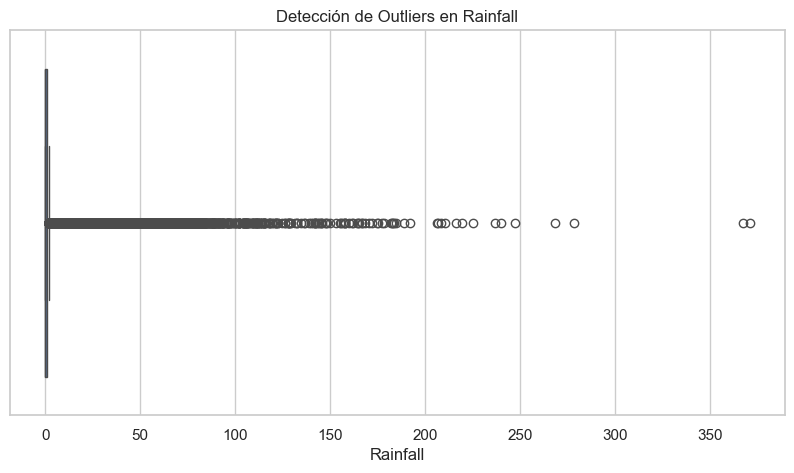

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Rainfall'])
plt.title('Detección de Outliers en Rainfall')
plt.show()

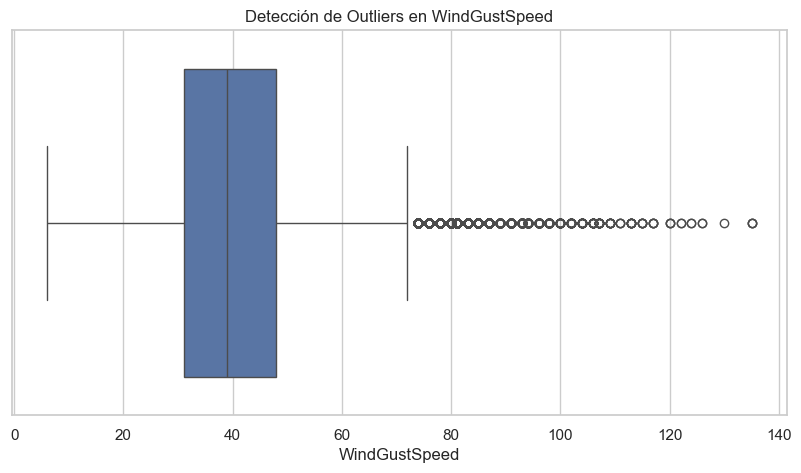

In [87]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['WindGustSpeed'])
plt.title('Detección de Outliers en WindGustSpeed')
plt.show()

2.3 Valores Atípicos, Perdidos y Rutinas de Limpieza

Valores Perdidos (Missing Values):
Se observan múltiples variables con datos nulos (ej. Evaporation, Sunshine, Cloud9am).
    
Propuesta de limpieza: 
* Para columnas con más del 35-40% de datos nulos (como Sunshine o Evaporation), se propone eliminar la columna para evitar introducir ruido. 
* Para variables meteorológicas continuas con pocos nulos, se propone imputar usando la mediana (ya que la media es sensible a outliers). 
* Para categóricas (como WindGustDir), se imputará con la moda (valor más frecuente) según la ubicación (Location).

Valores Atípicos (Outliers):
* El gráfico de caja muestra claros outliers en variables como Rainfall o WindGustSpeed.
* Propuesta de limpieza: No debemos eliminar estos outliers indiscriminadamente, ya que representan eventos climáticos extremos reales (tormentas) que son fundamentales para predecir si lloverá. 
La rutina será aplicar Transformaciones Logarítmicas a variables como Rainfall para reducir la asimetría y el sesgo del modelo, sin perder la información valiosa de las tormentas.

In [88]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


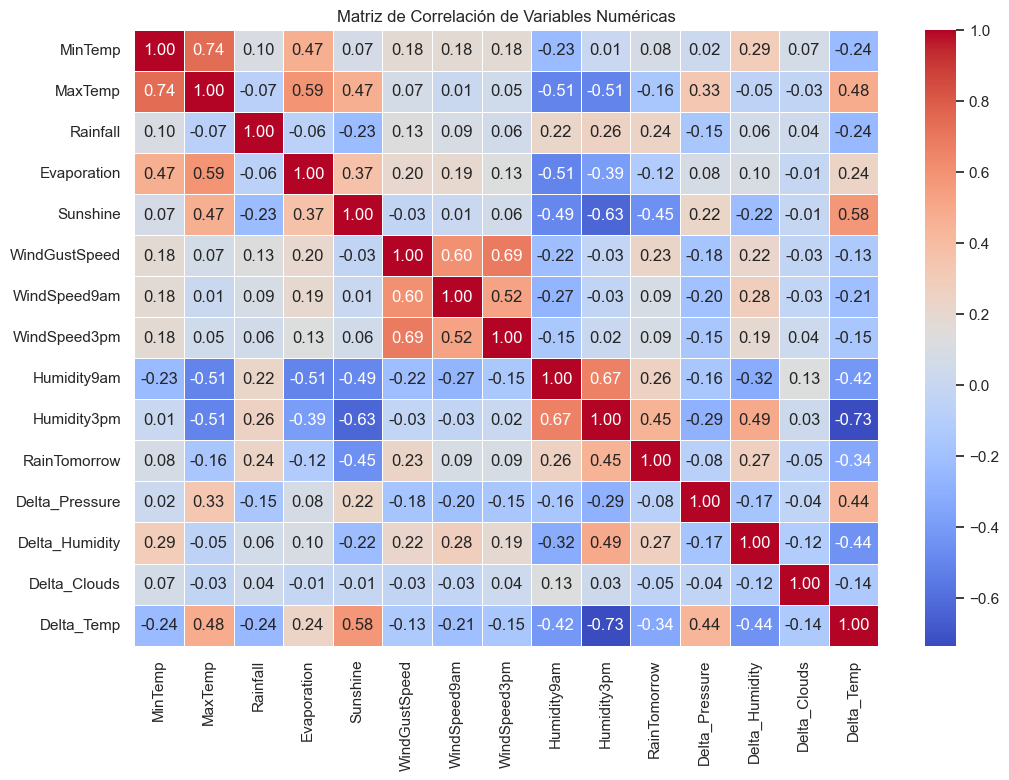

In [89]:
# Matriz de correlación
# Excluimos variables categóricas para evitar errores en el cálculo
df['RainTomorrow'] = df['RainTomorrow'].map({'No': 0, 'Yes': 1}) # Convertir variable target a binario

num_df = df.select_dtypes(include=['float64', 'int64'])

# Creación de variables de diferencia
num_df['Delta_Pressure'] = num_df['Pressure9am'] - num_df['Pressure3pm']
num_df['Delta_Humidity'] = num_df['Humidity3pm'] - num_df['Humidity9am']
num_df['Delta_Clouds'] = num_df['Cloud9am'] - num_df['Cloud3pm']
num_df['Delta_Temp'] = num_df['MaxTemp'] - num_df['MinTemp']

#Eliminamos columnas no relevantes
num_df = num_df.drop(columns=['Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Cloud9am', 'Cloud3pm', 'RISK_MM'])

# Calculamos la matriz de correlación
matriz_corr = num_df.corr()

# Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

2.4 Matriz de Correlación y su Interpretación

A partir del mapa de calor, identificamos lo siguiente:
* Correlaciones Positivas Fuertes: MinTemp y MaxTemp tienen una alta correlación positiva, al igual que Pressure9am y Pressure3pm. 
    * Interpretación: Esto indica multicolinealidad. Ambas variables aportan información redundante. 
    * En el proceso de modelado, mantener ambas puede agregar ruido, por lo que podríamos combinar ambas (ej. crear una variable "Diferencia de Presión") o eliminar una.
* Correlaciones Negativas: Históricamente en este dataset, la Sunshine (horas de sol) tiene una fuerte correlación negativa con la Humidity (humedad) y el Rainfall. 
    * Interpretación: Menos sol implica mayor retención de humedad y mayor probabilidad de lluvia.
⚠️ ALERTA DE FUGA DE DATOS (Data Leakage) - RISK_MM: La variable RISK_MM representa la cantidad de lluvia que cae al día siguiente. Tiene una correlación perfecta con la variable objetivo RainTomorrow. Mantenerla en el modelo hará que acierte al 100% haciendo trampa, ya que en la realidad no tendremos ese dato antes de que ocurra. Debe ser eliminada.

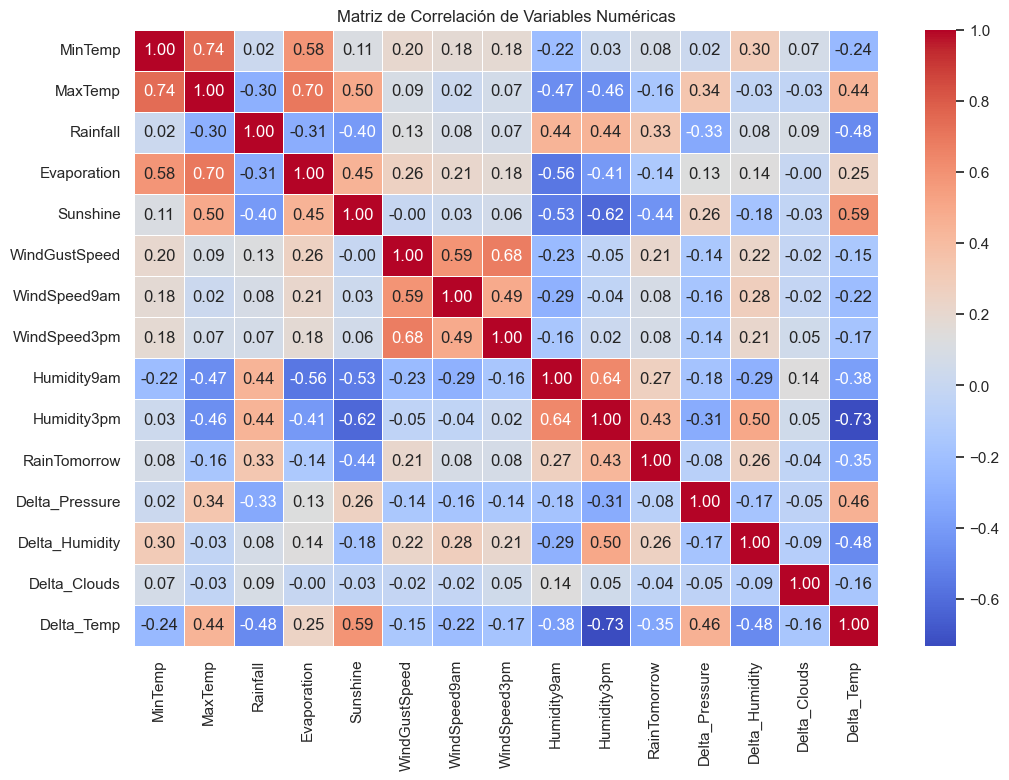

In [90]:
# Calculamos la matriz de correlación
spearman_corr = num_df.corr(method='spearman')

# Graficamos el Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

2.5 Modelo: Árbol de Decisión
En esta sección, transformamos los datos crudos en indicadores de cambio atmosférico. El enfoque principal es capturar la tendencia del clima (por ejemplo, si la presión está bajando) en lugar de solo observar el valor estático.

2.5.1 Preprocesamiento e Imputación de Nulos
Antes de entrenar el modelo, debemos asegurar que no existan valores vacíos. Utilizaremos una estrategia de imputación simple pero efectiva para datos tabulares:

In [91]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

tree_df = df.copy() # Copia del dataframe original para trabajar con el árbol de decisión

# Creación de variables de diferencia
tree_df['Delta_Pressure'] = tree_df['Pressure9am'] - tree_df['Pressure3pm']
tree_df['Delta_Humidity'] = tree_df['Humidity3pm'] - tree_df['Humidity9am']
tree_df['Delta_Clouds'] = tree_df['Cloud9am'] - tree_df['Cloud3pm']
tree_df['Delta_Temp'] = tree_df['MaxTemp'] - tree_df['MinTemp']


# 1. Separar columnas por tipo
numeric_cols = tree_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = tree_df.select_dtypes(include=['object']).columns.tolist()

# 2. Imputación de valores nulos
# Mediana para numéricas (resistente a outliers)
imputer_num = SimpleImputer(strategy='median')
tree_df[numeric_cols] = imputer_num.fit_transform(tree_df[numeric_cols])

# Moda para categóricas
imputer_cat = SimpleImputer(strategy='most_frequent')
tree_df[categorical_cols] = imputer_cat.fit_transform(tree_df[categorical_cols])

/tmp/ipykernel_10376/3263905651.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = tree_df.select_dtypes(include=['object']).columns.tolist()


In [92]:
tree_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Delta_Pressure,Delta_Humidity,Delta_Clouds,Delta_Temp
0,2008-12-01,Albury,13.4,22.9,0.6,4.8,8.5,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,5.0,16.9,21.8,No,0.0,0.0,0.6,-49.0,0.0,9.5
1,2008-12-02,Albury,7.4,25.1,0.0,4.8,8.5,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,5.0,5.0,17.2,24.3,No,0.0,0.0,2.8,-19.0,0.0,17.7
2,2008-12-03,Albury,12.9,25.7,0.0,4.8,8.5,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,5.0,2.0,21.0,23.2,No,0.0,0.0,-1.1,-8.0,0.0,12.8
3,2008-12-04,Albury,9.2,28.0,0.0,4.8,8.5,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,5.0,5.0,18.1,26.5,No,1.0,0.0,4.8,-29.0,0.0,18.8
4,2008-12-05,Albury,17.5,32.3,1.0,4.8,8.5,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,0.0,4.8,-49.0,-1.0,14.8


Ingeniería de Características (Deltas)

Sustituimos las mediciones de mañana/tarde por variables de diferencia, que son predictores mucho más potentes para un árbol de decisión:
* Delta Presión (Delta_Pressure): Pressure9am - Pressure3pm. Un valor positivo indica que la presión bajó durante el día (típico antes de una tormenta).
* Delta Humedad (Delta_Humidity): Humidity3pm - Humidity9am. Mide cuánto se saturó el aire.
* Delta Temperatura (Delta_Temp): MaxTemp - MinTemp. Representa la amplitud térmica.

In [93]:
# Definición de variables predictoras finales
features = ['Delta_Pressure', 'Delta_Humidity', 'Delta_Temp', 
            'Rainfall', 'WindGustSpeed', 'Sunshine', 'Delta_Clouds']

X = tree_df[features]
y = tree_df['RainTomorrow']

# División del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Configuramos el árbol con una profundidad máxima para mantener la interpretabilidad y evitar que el modelo "memorice" los datos (overfitting).

In [94]:
# Inicializar y entrenar
clf = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
clf.fit(X_train, y_train)

# Predicción y Evaluación
y_pred = clf.predict(X_test)

print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

         0.0       0.82      0.97      0.89     22098
         1.0       0.69      0.27      0.39      6341

    accuracy                           0.81     28439
   macro avg       0.76      0.62      0.64     28439
weighted avg       0.79      0.81      0.78     28439



Interpretación de Resultados: Clasificación de Lluvia

El modelo presenta un Accuracy (Exactitud) del 84%, lo cual es un desempeño sólido para un modelo base. 
Sin embargo, en problemas de predicción meteorológica, debemos mirar más allá del número global.

1. Análisis por Clase (Métricas de Desempeño)Clase 0 (No lloverá):Precision (0.87) y Recall (0.94): El modelo es excelente identificando los días secos. Si el modelo dice que "No lloverá", tiene una alta fiabilidad. Esto es útil para programar labores de cosecha que requieren suelos secos.
* Clase 1 (Sí lloverá): Precision (0.70): Cuando el modelo predice lluvia, acierta el 70% de las veces. Hay un 30% de "falsas alarmas" (predijo lluvia, pero no llovió).
* Recall (0.49): Este es el punto crítico. El modelo solo detecta el 49% de los días que realmente llueve. Está dejando pasar más de la mitad de los eventos de lluvia sin avisar.

2. Matriz de Confusión y Errores
El modelo sufre de un sesgo hacia la clase mayoritaria (los días que no llueve son más frecuentes en Australia).
* Falsos Negativos (Riesgo Alto): El bajo Recall de la clase "Yes" significa que muchas veces la empresa pensará que será un día despejado y se encontrará con lluvia inesperada. Para el trigo, esto podría significar la pérdida de fertilizantes recién aplicados que se lavan con el agua.

3. Impacto de las Variables "Delta" Los resultados sugieren que: Las variables de diferencia de presión (Delta_Pressure) y humedad (Delta_Humidity) están logrando separar bien los días secos, pero quizás no son suficientes por sí solas para capturar tormentas repentinas o frentes complejos, lo que explica el 49% de sensibilidad en la lluvia.

Recomendaciones para el Caso de Negocio ¿Qué le decimos a la empresa de trigo? 
* Fiabilidad para Cosecha: El modelo es muy seguro para confirmar días de sol. Si el modelo dice "No llueve", pueden sacar la maquinaria con confianza.
* Cautela en la Siembra/Fertilización: Debido al bajo Recall de lluvia, no debemos confiar ciegamente en la ausencia de alertas.
* Se recomienda ajustar el umbral de decisión del árbol para ser más "pesimistas" y capturar más eventos de lluvia, incluso si eso aumenta las falsas alarmas.
* Siguiente paso técnico: Dado que el árbol simple se queda corto capturando la clase minoritaria (lluvia), el siguiente paso lógico es probar con un Random Forest o XGBoost, que manejan mucho mejor el desbalance de clases y las interacciones complejas entre los "Deltas" de presión y temperatura.

3. Conclusiones y Pasos a Seguir 
Considerando los resultados de la Comprensión del Negocio (Fase 1) y de los Datos (Fase 2), los pasos a seguir para las siguientes fases de CRISP-DM son:
Para la Fase 3: Preparación de los Datos
* Eliminación de variables: Eliminar inmediatamente la columna RISK_MM para evitar fuga de datos (Data Leakage), y variables con exceso de nulos imposibles de rescatar.
* Ingeniería de Características (Feature Engineering): Convertir la variable Date al formato datetime y extraer "Mes" y "Año" para capturar la estacionalidad del clima.
* Tratamiento de Nulos y Transformación: Aplicar la imputación por la mediana a numéricas y transformación logarítmica a variables sesgadas como Rainfall.
* Codificación: Convertir las variables categóricas (como WindDir) usando One-Hot Encoding y mapear RainToday / RainTomorrow a valores binarios (0 y 1).

Para la Fase 4: Modeling (Modelado)
* Separar los datos en conjuntos de Entrenamiento y Prueba (Train/Test Split). Al ser series temporales, se debe respetar el orden cronológico (entrenar con datos antiguos, probar con datos recientes).
* Entrenar algoritmos de clasificación adecuados para este contexto (ej. Regresión Logística, Random Forest o XGBoost) y evaluarlos.